In [1]:
#!/usr/bin/env python3

import os
import numpy as np
import pandas as pd
import arviz as az

# --------------------------------------------------
# Config
# --------------------------------------------------
BASE_DATA_DIR = "../data"
FIG_DIR = "../figures/roni_dmi_city_extremes"
os.makedirs(FIG_DIR, exist_ok=True)

TARGET_VARS = ["wbt_daily_peak"]

Q_LEVELS = [0.95, 0.99]

SCENARIOS = [
    {"name": "El Niño (+1,0)",                 "N": +1.0, "D":  0.0},
    {"name": "La Niña (-1,0)",                 "N": -1.0, "D":  0.0},
    {"name": "pIOD (0,+1)",                    "N":  0.0, "D": +1.0},
    {"name": "nIOD (0,-1)",                    "N":  0.0, "D": -1.0},
    {"name": "La Niña + pIOD (-1,+1)",         "N": -1.0, "D": +1.0},
    {"name": "La Niña + nIOD (-1,-1)",         "N": -1.0, "D": -1.0},
    {"name": "Strong La Niña (-2,0)",          "N": -2.0, "D":  0.0},
    {"name": "Super La Niña (-2.5,0)",         "N": -2.5, "D":  0.0},
    {"name": "Strong La Niña + nIOD (-2,-1)",  "N": -2.0, "D": -1.0},
    {"name": "Strong El Niño (+2,0)",          "N": +2.0, "D":  0.0},
    {"name": "El Niño + pIOD (+1,+1)",         "N": +1.0, "D": +1.0},
    {"name": "El Niño + nIOD (+1,-1)",         "N": +1.0, "D": -1.0},
]

POOLED_SPACE_ORDER = {
    # must match fit_pooled_pair order in the model script exactly
    "gulf_coastal_pooled": ["doha", "dubai", "dammam"],
}

CITY_ORDER = [
    "muscat",
    "doha",
    "dubai",
    "dammam",
    "kuwait_city",
    "basra",
    "jeddah",
    "aden",
    "medina",
    "riyadh",
]

VAR_LABELS = {
    "wbt_daily_peak": "WBT",
}

YLABELS = {
    "wbt_daily_peak": "Change in extreme WBT",
}

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def gpd_quantile(u, sigma, xi, q, xi_tol=1e-6):
    xi = np.asarray(xi)
    sigma = np.asarray(sigma)

    out = np.empty(np.broadcast(xi, sigma).shape, dtype=float)
    near0 = np.abs(xi) < xi_tol

    out[~near0] = u + (sigma[~near0] / xi[~near0]) * ((1.0 - q) ** (-xi[~near0]) - 1.0)
    out[near0] = u + sigma[near0] * np.log(1.0 / (1.0 - q))
    return out

def stack_samples(da):
    return da.stack(sample=("chain", "draw")).values

def get_var_paths(var):
    run_dir = os.path.join(BASE_DATA_DIR, f"{var}_daily_city_runs")
    csv_path = os.path.join(run_dir, f"{var}_daily_gpd_city_roni_dmi_summary.csv")
    return run_dir, csv_path

def load_idata(run_dir, run_id):
    path = os.path.join(run_dir, f"idata_{run_id}.nc")
    if os.path.exists(path):
        return az.from_netcdf(path), path
    return None, path

def pretty_q(q):
    return f"p{int(round(q * 100))}"

# --------------------------------------------------
# Core computation
# --------------------------------------------------
def compute_impacts_for_var(var):
    run_dir, csv_path = get_var_paths(var)

    if not os.path.exists(csv_path):
        print(f"⚠️ missing summary CSV for {var}: {csv_path}")
        return None

    df = pd.read_csv(csv_path)
    rows = []

    for _, r in df.iterrows():
        city = r["city"]
        run_id = r["run_id"]

        # skip pooled hyper row
        if city == "ALL":
            continue

        # --------------------------
        # pooled city rows
        # --------------------------
        if ":" in run_id:
            base_run, city_name = run_id.split(":", 1)
            idata, expected_path = load_idata(run_dir, base_run)
            if idata is None:
                print(f"⚠️ missing pooled idata: {expected_path}")
                continue

            pooled_group = r.get("pooled_group", "")
            lookup_key = None

            if pooled_group in POOLED_SPACE_ORDER:
                lookup_key = pooled_group
            elif base_run in POOLED_SPACE_ORDER:
                lookup_key = base_run
            else:
                for key in POOLED_SPACE_ORDER:
                    if key in str(pooled_group) or key in str(base_run):
                        lookup_key = key
                        break

            if lookup_key is None:
                raise ValueError(
                    f"Unknown pooled space order for pooled_group='{pooled_group}' "
                    f"and base_run='{base_run}'"
                )

            order = POOLED_SPACE_ORDER[lookup_key]
            if city_name not in order:
                raise ValueError(f"City '{city_name}' not found in pooled order {order}")

            s = order.index(city_name)

            post = idata.posterior
            xi  = stack_samples(post["xi"])
            a   = stack_samples(post["a_s"].isel(space=s))
            bN  = stack_samples(post["bN_s"].isel(space=s))
            bD  = stack_samples(post["bD_s"].isel(space=s))
            bND = stack_samples(post["bND_s"].isel(space=s))

        # --------------------------
        # single-city rows
        # --------------------------
        else:
            idata, expected_path = load_idata(run_dir, run_id)
            if idata is None:
                print(f"⚠️ missing single-city idata: {expected_path}")
                continue

            post = idata.posterior
            xi  = stack_samples(post["xi"])
            a   = stack_samples(post["a"])
            bN  = stack_samples(post["bN"])
            bD  = stack_samples(post["bD"])
            bND = stack_samples(post["bND"])

        sigma0 = np.exp(a)
        u = float(r["u"])

        for scen in SCENARIOS:
            scen_name = scen["name"]
            Nval = scen["N"]
            Dval = scen["D"]

            NDval = Nval * Dval
            dlog = bN * Nval + bD * Dval + bND * NDval
            sigma1 = sigma0 * np.exp(dlog)

            for q in Q_LEVELS:
                x0 = gpd_quantile(u, sigma0, xi, q)
                x1 = gpd_quantile(u, sigma1, xi, q)
                dx = x1 - x0

                mean = float(dx.mean())
                lo, hi = az.hdi(dx, hdi_prob=0.94)

                rows.append({
                    "var": var,
                    "city": city,
                    "run_id": run_id,
                    "scenario": scen_name,
                    "quantile": q,
                    "delta_mean": mean,
                    "delta_hdi_low": float(lo),
                    "delta_hdi_high": float(hi),
                    "N": Nval,
                    "D": Dval,
                })

    if not rows:
        return None

    out_df = pd.DataFrame(rows)

    # optional city ordering
    out_df["city"] = pd.Categorical(out_df["city"], categories=CITY_ORDER, ordered=True)
    out_df = out_df.sort_values(["city", "quantile", "scenario"]).reset_index(drop=True)

    out_csv = os.path.join(run_dir, f"{var}_pointwise_extreme_changes.csv")
    out_df.to_csv(out_csv, index=False)
    print(f"✅ wrote: {out_csv}")

    return out_df

# --------------------------------------------------
# Main
# --------------------------------------------------
def main():
    for var in TARGET_VARS:
        print(f"\n=== Processing {var} ===")
        compute_impacts_for_var(var)

if __name__ == "__main__":
    main()



=== Processing wbt_daily_peak ===


ERROR 1: PROJ: proj_create_from_database: Open of /home/k16v981/.conda/envs/my_env/share/proj failed


✅ wrote: ../data/wbt_daily_peak_daily_city_runs/wbt_daily_peak_pointwise_extreme_changes.csv


Saved PNG: ../figures/city_roni_dmi/wbt_daily_peak_all_cities_roni_dmi_bigpanel.png
Saved PDF: ../figures/city_roni_dmi/wbt_daily_peak_all_cities_roni_dmi_bigpanel_manuscript.pdf


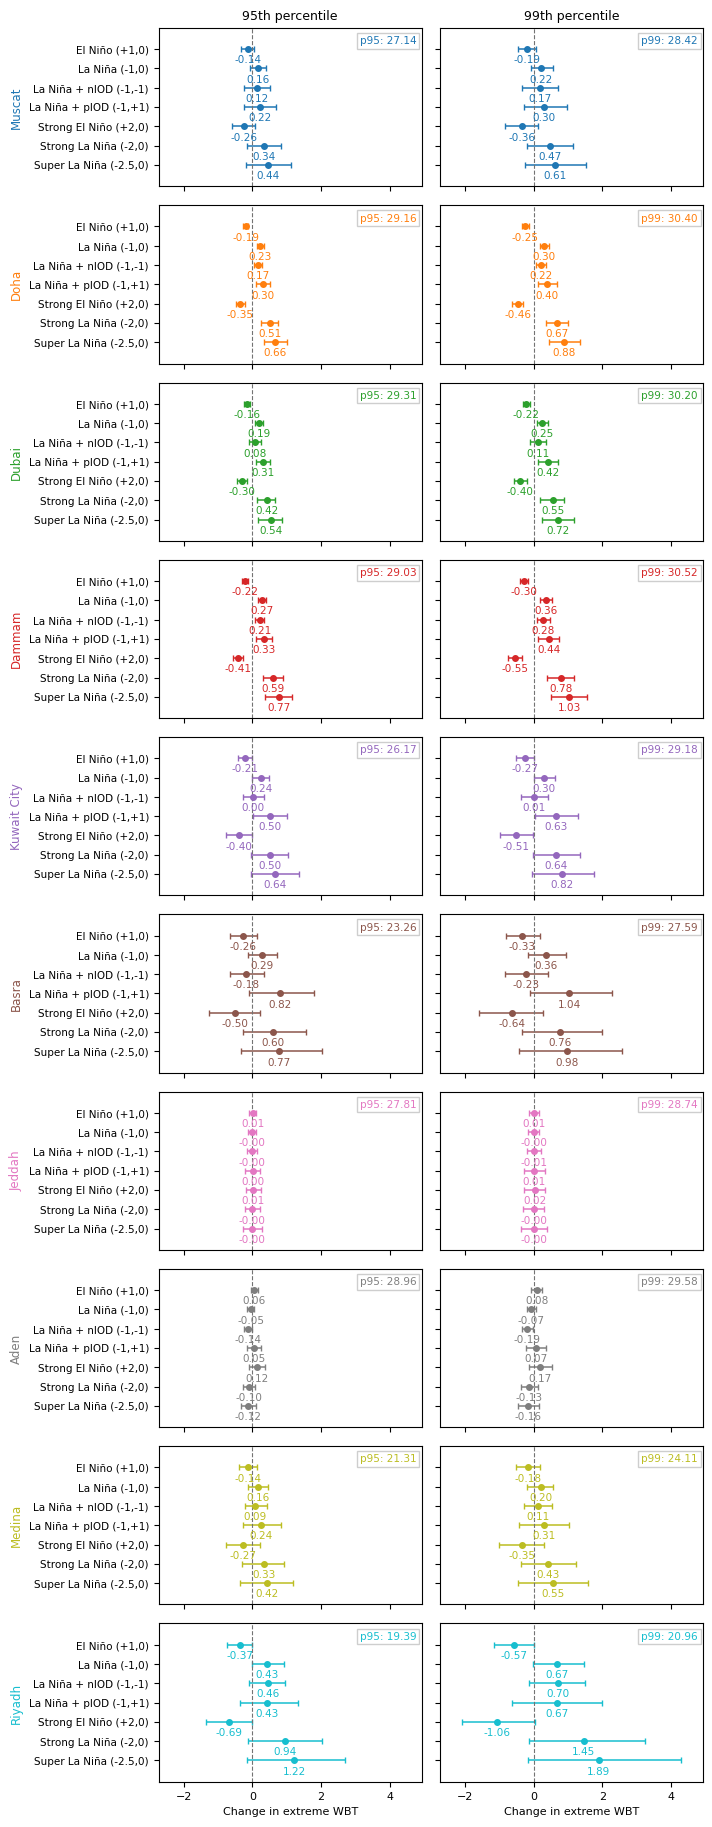

In [6]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt

# --------------------------------------------------
# ERL manuscript style
# --------------------------------------------------
ERL_RC = {
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "savefig.transparent": False,
    "path.simplify": False,
}

mpl.rcParams.update(ERL_RC)

# --------------------------------------------------
# Paths
# --------------------------------------------------
NETID = "k16v981"

BASE_DIR = f"/home/{NETID}/my_work/code/arabian_peninsula/bayesian_extremes/data"
DAILY_STATE_DIR = os.path.join(BASE_DIR, "DailyPeakState")
DATA_DIR = DAILY_STATE_DIR
DATA_GLOB = os.path.join(DATA_DIR, "DailyPeakState-*.nc")

BASE_DATA = "../data"
FIG_DIR = "../figures/city_roni_dmi"
os.makedirs(FIG_DIR, exist_ok=True)

# --------------------------------------------------
# Config
# --------------------------------------------------
TARGET_VARS = ["wbt_daily_peak"]

SCENARIOS_TO_PLOT = [
    "El Niño (+1,0)",
    "La Niña (-1,0)",
    "La Niña + nIOD (-1,-1)",
    "La Niña + pIOD (-1,+1)",
    "Strong El Niño (+2,0)",
    "Strong La Niña (-2,0)",
    "Super La Niña (-2.5,0)",
]

QUANTILES = [0.95, 0.99]

CITY_ORDER = [
    "muscat",
    "doha",
    "dubai",
    "dammam",
    "kuwait_city",
    "basra",
    "jeddah",
    "aden",
    "medina",
    "riyadh",
]

CITY_LABELS = {
    "muscat": "Muscat",
    "doha": "Doha",
    "dubai": "Dubai",
    "dammam": "Dammam",
    "kuwait_city": "Kuwait City",
    "basra": "Basra",
    "jeddah": "Jeddah",
    "aden": "Aden",
    "medina": "Medina",
    "riyadh": "Riyadh",
}

VAR_LABELS = {
    "wbt_daily_peak": "Wet-Bulb Temperature",
}

# --------------------------------------------------
# City coordinates
# --------------------------------------------------
CITY_COORDS = {
    "muscat": (23.5880, 58.3829),
    "doha": (25.2854, 51.5310),
    "dubai": (25.2048, 55.2708),
    "dammam": (26.4207, 50.0888),
    "kuwait_city": (29.3759, 47.9774),
    "basra": (30.5085, 47.7835),
    "jeddah": (21.4858, 39.1925),
    "aden": (12.7855, 45.0187),
    "medina": (24.5247, 39.5692),
    "riyadh": (24.7136, 46.6753),
}

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def pretty_city(city: str) -> str:
    return CITY_LABELS.get(city, city.replace("_", " ").title())

def compute_global_xlim(df, scenarios_to_plot):
    sub = df[df["scenario"].isin(scenarios_to_plot)].copy()
    if sub.empty:
        return (-1, 1)

    xmin = np.nanmin(sub["delta_hdi_low"].values)
    xmax = np.nanmax(sub["delta_hdi_high"].values)

    if not np.isfinite(xmin) or not np.isfinite(xmax):
        return (-1, 1)

    span = xmax - xmin
    pad = 0.10 * span if span > 0 else 0.2
    return xmin - pad, xmax + pad

def detect_lat_lon_names(ds):
    lat_candidates = ["lat", "latitude", "y"]
    lon_candidates = ["lon", "longitude", "x"]

    lat_name = next((n for n in lat_candidates if n in ds.coords or n in ds.dims), None)
    lon_name = next((n for n in lon_candidates if n in ds.coords or n in ds.dims), None)

    if lat_name is None or lon_name is None:
        raise ValueError("Could not detect lat/lon names in dataset.")

    return lat_name, lon_name

def compute_actual_city_quantiles(data_glob, city_coords, var_name="wbt_daily_peak"):
    files = sorted(glob.glob(data_glob))
    if not files:
        raise FileNotFoundError(f"No files matched: {data_glob}")

    ds = xr.open_mfdataset(files, combine="by_coords", parallel=False, engine = "h5netcdf")

    if var_name not in ds:
        raise KeyError(f"{var_name} not found in dataset.")

    da = ds[var_name]
    lat_name, lon_name = detect_lat_lon_names(ds)

    # detect lon convention
    lon_vals = ds[lon_name].values
    lon_is_360 = np.nanmax(lon_vals) > 180

    city_q = {}
    for city, (lat, lon) in city_coords.items():
        lon_use = lon % 360 if lon_is_360 else lon

        point = da.sel(
            {lat_name: lat, lon_name: lon_use},
            method="nearest"
        )

        vals = np.asarray(point.values).ravel()
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            city_q[city] = {0.95: np.nan, 0.99: np.nan}
        else:
            city_q[city] = {
                0.95: float(np.nanquantile(vals, 0.95)),
                0.99: float(np.nanquantile(vals, 0.99)),
            }

    ds.close()
    return city_q

# --------------------------------------------------
# Precompute actual p95 / p99 from DailyPeakState
# --------------------------------------------------
actual_city_quantiles = compute_actual_city_quantiles(
    DATA_GLOB,
    CITY_COORDS,
    var_name="wbt_daily_peak"
)

# --------------------------------------------------
# Main plotting
# --------------------------------------------------
for var in TARGET_VARS:
    csv_path = f"{BASE_DATA}/{var}_daily_city_runs/{var}_pointwise_extreme_changes.csv"

    if not os.path.exists(csv_path):
        print("Missing:", csv_path)
        continue

    impact_df = pd.read_csv(csv_path)
    impact_df = impact_df[impact_df["scenario"].isin(SCENARIOS_TO_PLOT)].copy()

    if impact_df.empty:
        print(f"No matching scenarios found for {var}")
        continue

    cities_present = impact_df["city"].dropna().unique().tolist()
    cities = [c for c in CITY_ORDER if c in cities_present]

    if not cities:
        print(f"No matching cities found for {var}")
        continue

    xlim = compute_global_xlim(impact_df, SCENARIOS_TO_PLOT)

    nrows = len(cities)
    ncols = len(QUANTILES)

    fig_height = max(1.75 * nrows + 0.8, 10.5)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(7.2, fig_height),
        sharex=True,
        sharey=False,
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = axes[:, np.newaxis]

    cmap = plt.get_cmap("tab10")
    city_colors = {city: cmap(i % 10) for i, city in enumerate(cities)}

    y_spacing = 4.0
    y = np.arange(len(SCENARIOS_TO_PLOT)) * y_spacing

    for i, city in enumerate(cities):
        dfc = impact_df[impact_df["city"] == city].copy()
        city_color = city_colors[city]

        for j, q in enumerate(QUANTILES):
            ax = axes[i, j]

            sub = (
                dfc[dfc["quantile"] == q]
                .set_index("scenario")
                .reindex(SCENARIOS_TO_PLOT)
            )

            mean = sub["delta_mean"].values
            lo = sub["delta_hdi_low"].values
            hi = sub["delta_hdi_high"].values

            ax.errorbar(
                mean,
                y,
                xerr=[mean - lo, hi - mean],
                fmt="o",
                capsize=2.5,
                linewidth=1.1,
                color=city_color,
                ecolor=city_color,
                markersize=4.0,
            )

            ax.axvline(0, linestyle="--", linewidth=0.8, color="0.45")

            # put change value beneath each point
            dy = 0.3 * y_spacing
            for k, m in enumerate(mean):
                if np.isfinite(m):
                    ax.text(
                        m,
                        y[k] + dy,
                        f"{m:.2f}",
                        ha="center",
                        va="top",
                        fontsize=7.5,
                        color=city_color,
                    )

            # only show the matching actual threshold for that column
            actual_q = actual_city_quantiles.get(city, {})
            qval = actual_q.get(q, np.nan)

            ax.text(
                0.98, 0.95,
                f"p{int(q*100)}: {qval:.2f}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=7.5,
                color=city_color,
                bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.95, pad=2.0),
            )

            ax.set_xlim(xlim)
            ax.set_yticks(y)

            if j == 0:
                ax.set_yticklabels(SCENARIOS_TO_PLOT, fontsize=7.5)
                ax.set_ylabel(pretty_city(city), fontsize=8.5, color=city_color)
            else:
                ax.set_yticklabels([])

            if i == 0:
                ax.set_title(f"{int(q * 100)}th percentile", fontsize=9)

            if i == nrows - 1:
                ax.set_xlabel("Change in extreme WBT", fontsize=8)

            ax.set_ylim(y[-1] + 1.1 * y_spacing, -1.1 * y_spacing)



    # -------------------------------
    # Save PNG WITH title
    # -------------------------------
    st = fig.suptitle(
        f"{VAR_LABELS.get(var, var)} response to ENSO / IOD scenarios",
        fontsize=10,
        y=0.995,
    )
    
    fig.tight_layout(rect=[0, 0, 1, 0.985])
    
    png_out = f"{FIG_DIR}/{var}_all_cities_roni_dmi_bigpanel.png"
    fig.savefig(png_out, dpi=300, bbox_inches="tight")
    print("Saved PNG:", png_out)
    
    # -------------------------------
    # Save PDF WITHOUT title
    # -------------------------------
    st.remove()
    
    fig.subplots_adjust(top=0.985)
    
    pdf_out = f"{FIG_DIR}/{var}_all_cities_roni_dmi_bigpanel_manuscript.pdf"
    fig.savefig(pdf_out)
    print("Saved PDF:", pdf_out)
    
    plt.show()
    plt.close()
